## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 11 · The PyPSA-LAEP interface: clusters, retrofit catalogue, quantities and hourly demand

What the optimiser needs, in four files (`outputs/pypsa_interface/`), built from the calibrated
archetype tier (notebook 06) and the retrofit logic of notebook 10:

1. **Building-to-cluster map** — every building footprint to a cluster = thermal archetype ×
   retrofit-eligibility class × electricity supply zone, with the ward, dwelling count, heated floor
   area, shared block and *how* the zone was assigned (the nearest-substation Voronoi inference is
   labelled as an inference, never as a verified connection).
2. **Retrofit catalogue** — per cluster the baseline R0 and the feasible packages R1 (light fabric:
   loft top-up, draught proofing, cavity fill) and R2 (deep fabric: R1 + solid-wall insulation, flat
   roof, glazing), the explicit measure sets and the before/after building parameters. Packages are
   simulated as combinations, never summed from single measures.
3. **Physical quantities** — exposed opaque wall, roof and window areas, dwellings and buildings
   needing shared works, with the cost scope (dwelling / building) and quantity source.
4. **Hourly demand profiles** — per cluster and package the three useful-energy vectors, space heat,
   hot water and non-heating electricity, on one shared time axis; R0/R1/R2 are three descriptions of
   the same dwellings. The profile library is delivered twice: as the calibrated households heat today
   (gas-era behaviour) and as heat-pump households heat (the GB trial shapes of Watson et al. 2021), so the
   optimiser can switch the space-heat shape of a cluster when it electrifies it.
5. **Building-fabric flexibility** — per cluster the thermal time constant, thermal capacity, the energy a
   3 K window stores, standing loss and heat-pump capacity (Halloran 2024), the parameters of a thermal
   energy store in a PyPSA heat bus.

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import config as CFG
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_FIXED, make_representatives, _stock_delivered, evaluate_on)
from ukubem import metrics as M, maps, profiles, measures, stock
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
theta = json.load(open(UBEM_OUT / "06_calibrated_theta.json")); phys, post = theta["physics"], theta["post"]
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
folds = pd.read_csv(CV_FOLDS)
A_cal = UKGeometryAssumptions().with_(wall_u_scale=phys["wall_u_scale"], roof_u_scale=phys["roof_u_scale"], window_u_scale=phys["window_u_scale"],
                                      infil_scale=phys["infil_scale"], gains_scale=phys["gains_scale"], setpoint_offset_c=phys["setpoint_offset_c"],
                                      stochastic_setback_c=phys.get("setback_c", 12.0))
inten_cal = pd.read_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv", index_col=0)
stock_cal = pd.read_parquet(UBEM_OUT / "06_stock_calibrated.parquet")
print(f"{len(inputs):,} dwellings, {len(reps)} representatives, {folds['fold'].nunique()} spatial folds; calibrated physics {phys}")

57,300 dwellings, 102 representatives, 7 spatial folds; calibrated physics {'wall_u_scale': 1.0652602409167062, 'roof_u_scale': 1.1248578219743166, 'window_u_scale': 1.25, 'infil_scale': 0.8129959823081263, 'gains_scale': 0.8155295436843902, 'setpoint_offset_c': 1.0, 'setback_c': 15.691329877128062}


In [3]:
from ukubem import pypsa_export as PX, pubstyle, accounting, heatpumps as HP, flexibility as FX
pubstyle.apply()
SCOPE = "ten_wards"            # "ten_wards" (PyPSA-LAEP study area, substation zones) | "borough" (LSOA zones outside the study-area wards)
TARGET_SET = "planning"   # parameters/retrofit_measures/fabric_targets.json: "planning" (the code-style targets of the scenarios) or "register" (stricter register values)
CLUSTER_RESOLUTION = "planning"   # "planning": archetype x wall-measure class x zone, small groups pooled per zone | "fine": full eligibility signature
MIN_CLUSTER_DWELLINGS = 10
CASE = {"case_id": "GF2021_TMYx_CHAP_cal08", "year": 2021,
        "description": "Farnborough TMYx 2007-2021 weather; CREST/CHAP stochastic households (EFUS 2011 microdata; three stratified household draws per representative, Latin hypercube over regime and thermostat quantiles); "
                       "ISO 52016 physics calibrated to DESNZ 2021 LSOA meters (notebook 06); BREDEM/SAP hot water and appliances; "
                       "useful energy, no system efficiencies"}
OUT_PX = OUT / "pypsa_interface"; OUT_PX.mkdir(exist_ok=True); FIG_PX = FIG / "pypsa_interface"; FIG_PX.mkdir(exist_ok=True)
scope = inputs[inputs["in_study_area"].astype(bool)] if SCOPE == "ten_wards" else inputs
L = maps.load_layers(CFG, town_only=(SCOPE == "ten_wards"))
a_file = UBEM_OUT / "11_envelope_areas.parquet"
if a_file.exists() and len(pd.read_parquet(a_file)) >= len(scope):
    areas = pd.read_parquet(a_file).reindex(scope.index)
else:
    t0 = time.time(); areas = measures.envelope_areas(scope); areas.to_parquet(a_file); print(f"envelope areas for {len(scope):,} dwellings in {(time.time()-t0)/60:.1f} min")
print(f"scope {SCOPE}: {len(scope):,} dwellings, {scope['toid'].nunique():,} buildings")

scope ten_wards: 28,663 dwellings, 21,631 buildings


## 1 · Building-to-cluster map

In [4]:
zones = PX.electricity_zones(scope, CFG)
elig = PX.eligibility_class(scope, TARGET_SET)
cid, clusters = PX.build_clusters(scope, zones, elig, resolution=CLUSTER_RESOLUTION, min_dwellings=MIN_CLUSTER_DWELLINGS)
bmap = PX.building_cluster_map(scope, cid, zones, elig)
bmap.to_csv(OUT_PX / "building_cluster_map.csv", index=False); clusters.to_csv(OUT_PX / "cluster_summary.csv", index=False)
print(f"{len(clusters):,} clusters from {clusters['dwelling_count'].sum():,} dwellings in {bmap['building_id'].nunique():,} buildings and {clusters['electricity_zone_id'].nunique()} zones; "
      f"{(clusters['archetype_id'] == 'MIX').sum()} pooled MIX clusters hold {clusters.loc[clusters['archetype_id'] == 'MIX', 'dwelling_count'].sum():,} dwellings")
print("zone assignment:", zones["network_assignment_method"].value_counts().to_dict())
print("cluster size: median %d dwellings, %d clusters with fewer than 5 dwellings (%.0f%% of dwellings in clusters of 20+)" % (
    clusters["dwelling_count"].median(), (clusters["dwelling_count"] < 5).sum(), 100 * clusters.loc[clusters["dwelling_count"] >= 20, "dwelling_count"].sum() / clusters["dwelling_count"].sum()))
clusters.sort_values("dwelling_count", ascending=False).head(8)

1,532 clusters from 28,663 dwellings in 21,631 buildings and 272 zones; 701 pooled MIX clusters hold 12,083 dwellings
zone assignment: {'spatial_inference_nearest_substation': 28662, 'assumed_zone_lsoa': 1}
cluster size: median 15 dwellings, 151 clusters with fewer than 5 dwellings (62% of dwellings in clusters of 20+)


,cluster_id,archetype_id,n_archetypes,archetype_mix,eligibility_class,electricity_zone_id,network_assignment_method,building_count,dwelling_count,heated_floor_area_m2,ward,in_ten_wards,n_S.ElecResistive,n_S.ElecStorage,n_S.GasBoiler,n_S.GasCommunal,n_S.HeatPump,n_S.LPGBoiler,n_S.OilBoiler,n_S.SolidFuel
319,C.Flat.3|Wnone|SUB:SPN-S000000181539,C.Flat.3,1,C.Flat.3:177,Wnone,SUB:SPN-S000000181539,spatial_inference_nearest_substation,2,177,9366.0,Stoke,1.0,1,0,0,176,0,0,0,0
344,C.Flat.4|Wnone|SUB:SPN-S000000174751,C.Flat.4,1,C.Flat.4:126,Wnone,SUB:SPN-S000000174751,spatial_inference_nearest_substation,10,126,7830.0,Stoke,1.0,21,1,18,83,1,0,2,0
303,C.Flat.3|Wnone|SUB:SPN-S000000171606,C.Flat.3,1,C.Flat.3:123,Wnone,SUB:SPN-S000000171606,spatial_inference_nearest_substation,5,123,7385.0,Stoke,1.0,0,0,123,0,0,0,0,0
310,C.Flat.3|Wnone|SUB:SPN-S000000171834,C.Flat.3,1,C.Flat.3:104,Wnone,SUB:SPN-S000000171834,spatial_inference_nearest_substation,2,104,5527.0,Stoke,1.0,92,0,12,0,0,0,0,0
318,C.Flat.3|Wnone|SUB:SPN-S000000175026,C.Flat.3,1,C.Flat.3:98,Wnone,SUB:SPN-S000000175026,spatial_inference_nearest_substation,4,98,6692.0,Stoke,1.0,0,2,1,95,0,0,0,0
331,C.Flat.4|Wnone|SUB:SPN-S000000171804,C.Flat.4,1,C.Flat.4:96,Wnone,SUB:SPN-S000000171804,spatial_inference_nearest_substation,5,96,7338.0,Castle,1.0,61,1,10,22,2,0,0,0
486,C.Semi.1|Wnone|SUB:SPN-S000000171859,C.Semi.1,1,C.Semi.1:93,Wnone,SUB:SPN-S000000171859,spatial_inference_nearest_substation,93,93,8561.5,Merrow,1.0,2,3,87,0,1,0,0,0
449,C.Semi.1|Wnone|SUB:SPN-S000000171719,C.Semi.1,1,C.Semi.1:88,Wnone,SUB:SPN-S000000171719,spatial_inference_nearest_substation,88,88,7667.5,Bellfields & Slyfield,1.0,1,2,85,0,0,0,0,0


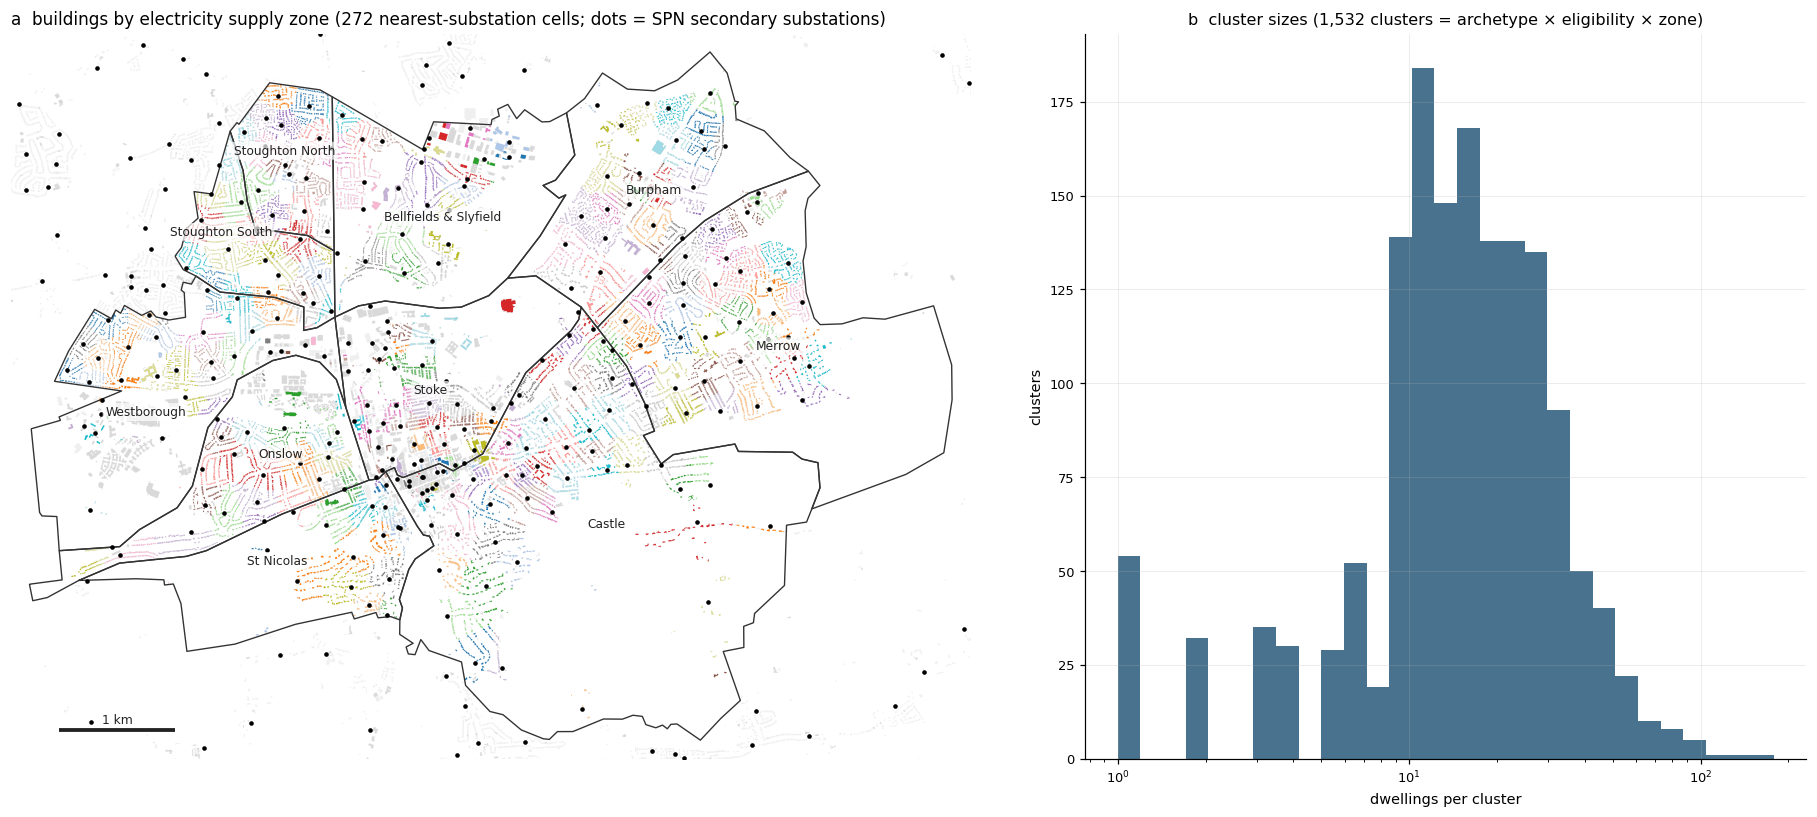

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), gridspec_kw={"width_ratios": [1.45, 1]})
maps.base_map(axes[0], L)
zb = bmap.groupby("building_id")["electricity_zone_id"].first()
codes = pd.Series(pd.factorize(zb)[0] % 20, index=zb.index)
maps.building_map(axes[0], L, codes, cmap="tab20", label="electricity zone (colour cycles every 20 zones)", vmin=-0.5, vmax=19.5, legend=False)
if L.get("substations") is not None:
    sub = L["substations"].cx[axes[0].get_xlim()[0]:axes[0].get_xlim()[1], axes[0].get_ylim()[0]:axes[0].get_ylim()[1]]
    sub.plot(ax=axes[0], color="k", markersize=4, zorder=8)
maps.finish(axes[0], L, title=f"a  buildings by electricity supply zone ({clusters['electricity_zone_id'].nunique()} nearest-substation cells; dots = SPN secondary substations)")
cs = clusters["dwelling_count"]
axes[1].hist(cs, bins=np.logspace(0, np.log10(cs.max() + 1), 30), color=pubstyle.PALETTE[0], alpha=0.8); axes[1].set_xscale("log")
axes[1].set_xlabel("dwellings per cluster"); axes[1].set_ylabel("clusters"); axes[1].set_title(f"b  cluster sizes ({len(clusters):,} clusters = archetype × eligibility × zone)")
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PX / "11_cluster_map"); plt.show()

## 2 · Retrofit catalogue and 3 · physical quantities

In [6]:
options, msets, tsets = PX.retrofit_options(scope, cid, areas, TARGET_SET)
options.to_csv(OUT_PX / "retrofit_options.csv", index=False)
json.dump(msets, open(OUT_PX / "measure_sets.json", "w"), indent=2); json.dump(tsets, open(OUT_PX / "thermal_parameter_sets.json", "w"), indent=2)
qty = PX.retrofit_quantities(scope, cid, areas, TARGET_SET); qty.to_csv(OUT_PX / "retrofit_quantities.csv", index=False)
print("options:", options.groupby("package_id")["eligible"].mean().round(3).to_dict(), "(share of clusters where the package applies)")
q = qty.groupby(["package_id", "measure_id"]).agg(quantity=("quantity", "sum"), unit=("unit", "first"), dwellings=("n_dwellings_applied", "sum"), buildings=("n_buildings_applied", "sum"))
q["quantity"] = q["quantity"].round(0); q

options: {'R0': 1.0, 'R1': 0.909, 'R2': 0.933} (share of clusters where the package applies)


quantity      unit  dwellings  buildings
package_id measure_id                                                      
R1         cavity_fill             696103.0        m2       7205       6326
           draught_proofing         28663.0  dwelling      28663      23698
           loft_topup             1257269.0        m2      18016      17331
           shared_enabling_works     2096.0  building       3388       2096
R2         cavity_fill             696103.0        m2       7205       6326
           draught_proofing         28663.0  dwelling      28663      23698
           flat_roof                40401.0        m2        574        449
           glazing_upgrade          26867.0        m2       1592       1285
           loft_topup             1257269.0        m2      18016      17331
           shared_enabling_works     2523.0  building       4320       2523
           solid_wall_iwi          399858.0        m2       4483       3919

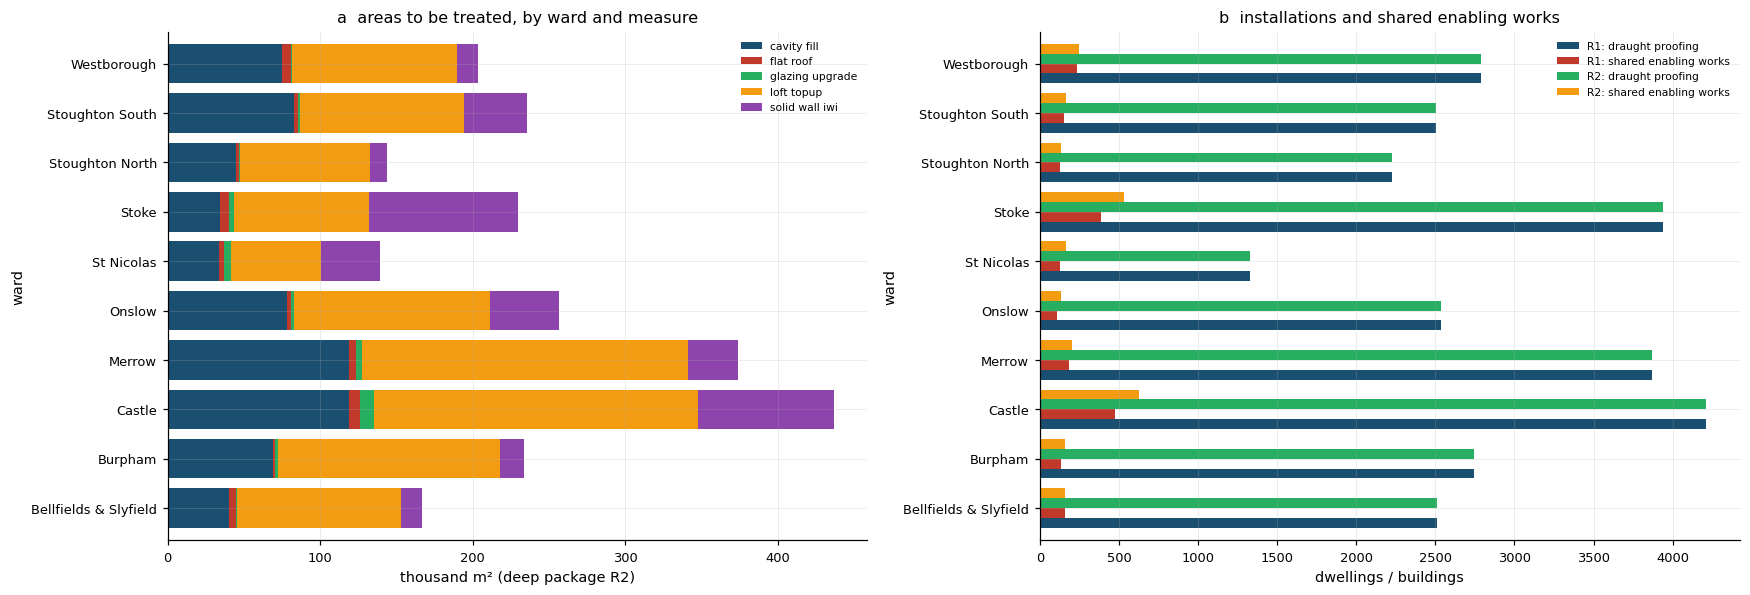

In [7]:
qw = qty.merge(clusters[["cluster_id", "ward"]], on="cluster_id")
piv = qw[qw["unit"] == "m2"].pivot_table(index="ward", columns=["package_id", "measure_id"], values="quantity", aggfunc="sum").fillna(0) / 1e3
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
piv["R2"].rename(columns=lambda c: c.replace("_", " ")).plot.barh(ax=axes[0], stacked=True, width=0.8); axes[0].set_xlabel("thousand m² (deep package R2)"); axes[0].set_title("a  areas to be treated, by ward and measure"); axes[0].legend(fontsize=7)
dw = qw[qw["unit"] != "m2"].pivot_table(index="ward", columns=["package_id", "measure_id"], values="quantity", aggfunc="sum").fillna(0)
dw.columns = [f"{p}: {m.replace('_', ' ')}" for p, m in dw.columns]
dw.plot.barh(ax=axes[1], width=0.8); axes[1].set_xlabel("dwellings / buildings"); axes[1].set_title("b  installations and shared enabling works"); axes[1].legend(fontsize=7)
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PX / "11_retrofit_quantities"); plt.show()

## 4 · Hourly demand profiles

Space heat comes from the representatives (sub-archetype × size class) re-simulated under each package
with the calibrated physics and the same household seeds; hot water and non-heating electricity keep
the BREDEM/SAP annual quantities of every dwelling with the hourly shapes of the CHAP household
model. Every cluster profile is the floor-area-weighted sum of its groups.

In [8]:
from joblib import Parallel, delayed
from ukubem.runner import schedule_for_row
key = reps.set_index("dwelling_id")[["construction_sa", "size_class"]]
idx = pd.date_range(f"{CASE['year']}-01-01", periods=8760, freq="h", tz="UTC")

def rep_hourly(file, inp_rep, A, n_real):
    if Path(file).exists():
        z = np.load(file, allow_pickle=True); return z["Q_W"], pd.DataFrame(z["meta"], columns=["dwelling_id", "realisation", "construction_sa", "size_class", "heating_pattern", "A_floor"])
    rows_rep = inp_rep.loc[reps["dwelling_id"].to_numpy()]
    tasks = [(rows_rep.iloc[i:i + 1], SEED, k) for k in range(n_real) for i in range(len(rows_rep))]     # stratified draws, paired across packages
    res = Parallel(n_jobs=N_JOBS, batch_size=1)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A, True, s, CASE["year"], post, True, 60, k, n_real) for c, s, k in tasks)
    Q, meta = [], []
    for (c, s, k), r in zip(tasks, res):
        r = r[0]
        if "hourly_Q_HC_W" in r:
            Q.append(np.clip(np.asarray(r["hourly_Q_HC_W"], np.float32), 0, None)); did = int(r["dwelling_id"]); meta.append([did, k, key.loc[did, "construction_sa"], key.loc[did, "size_class"], r.get("heating_pattern"), r["A_floor"]])
    Q = np.stack(Q); meta = pd.DataFrame(meta, columns=["dwelling_id", "realisation", "construction_sa", "size_class", "heating_pattern", "A_floor"]); np.savez(file, Q_W=Q, meta=meta.to_numpy(dtype=object)); return Q, meta

def assumptions_for(ph):
    return UKGeometryAssumptions().with_(wall_u_scale=ph["wall_u_scale"], roof_u_scale=ph["roof_u_scale"], window_u_scale=ph["window_u_scale"], infil_scale=ph["infil_scale"],
                                         gains_scale=ph["gains_scale"], setpoint_offset_c=ph["setpoint_offset_c"], stochastic_setback_c=ph.get("setback_c", 12.0))
t0 = time.time(); rep_profiles = {}
for pkg, spec in PX.R_PACKAGES.items():
    inp_p, applied = measures.apply_package(inputs, spec["measures"], TARGET_SET)
    ph = dict(phys)
    if "draught_proofing" in spec["measures"]:
        ph["infil_scale"] = phys["infil_scale"] * measures.ASSUMPTIONS["targets"][TARGET_SET]["draught_ach_factor"]
    file = UBEM_OUT / ("09_representative_hourly.npz" if pkg == "R0" else f"11_representative_hourly_{pkg}.npz")
    Q, meta = rep_hourly(file, inp_p, assumptions_for(ph), n_real=3)
    rep_profiles[pkg] = PX.group_profiles(Q, meta)
    print(f"{pkg}: {Q.shape[0]} representative-years, mean {Q.mean() * 8760 / 1e3 / meta['A_floor'].astype(float).mean():.1f} kWh/m2   [{(time.time()-t0)/60:.1f} min]")
# level-match: every group's R0 annual per m2 equals the calibrated intensity of notebook 06 (its shape comes from
# the hourly realisations); R1 / R2 keep their simulated ratio to R0
cal_m2 = inten_cal.reset_index().set_index(["construction_sa", "size_class"])["Q_H_kWh_m2"] * post["weather_scale"]
factors = {}
for g, prof in rep_profiles["R0"].items():
    annual = prof.sum() / 1000.0
    factors[g] = float(cal_m2.get(g, annual) / annual) if annual > 0 else 1.0
for pkg in rep_profiles:
    rep_profiles[pkg] = {g: v * factors.get(g, 1.0) for g, v in rep_profiles[pkg].items()}
f = pd.Series(factors); print(f"level-match factors (calibrated / hourly-mean intensity): median {f.median():.3f}, p5-p95 {f.quantile(0.05):.2f}-{f.quantile(0.95):.2f}")
# hot-water and electricity shapes of the representatives' households (same seeds as the R0 runs)
rows_rep = inputs.loc[reps["dwelling_id"].to_numpy()]
def shapes(i, k):
    r = rows_rep.iloc[i]; did = rows_rep.index[i]
    _, sch = schedule_for_row(r, did, assumptions_for(phys), True, SEED, CASE["year"], 60, k, 3)
    return did, np.asarray(sch["dhw_kWh"], float), np.asarray(sch["elec_w"], float)
sh = Parallel(n_jobs=N_JOBS)(delayed(shapes)(i, k) for k in range(3) for i in range(len(rows_rep)))
dsh, esh = {}, {}
for did, dh, el in sh:
    g = (key.loc[did, "construction_sa"], key.loc[did, "size_class"])
    dsh.setdefault(g, []).append(dh / max(dh.sum(), 1e-9)); esh.setdefault(g, []).append(el / max(el.sum(), 1e-9))
dhw_shapes = {g: np.mean(v, axis=0) for g, v in dsh.items()}; elec_shapes = {g: np.mean(v, axis=0) for g, v in esh.items()}
print(f"shapes for {len(dhw_shapes)} groups in {(time.time()-t0)/60:.1f} min")

R0: 306 representative-years, mean 111.3 kWh/m2   [0.0 min]
R1: 306 representative-years, mean 71.9 kWh/m2   [0.0 min]
R2: 306 representative-years, mean 54.6 kWh/m2   [0.0 min]
level-match factors (calibrated / hourly-mean intensity): median 1.000, p5-p95 1.00-1.00


shapes for 102 groups in 0.2 min


In [9]:
masks = accounting.family_masks(scope["systems_fam"].astype(str).to_numpy(), scope["gas_connected"].fillna(False).to_numpy(dtype=bool))
usage = accounting.usage_for(scope["floor_area_final"].to_numpy(float), masks)
t0 = time.time()
lib, weights, totals = PX.write_demand_profiles(OUT_PX / "demand_profiles.parquet", scope, cid, rep_profiles, dhw_shapes, elec_shapes, usage, CASE["case_id"], idx)
lib.to_parquet(OUT_PX / "demand_profile_library.parquet", index=False); weights.to_csv(OUT_PX / "cluster_profile_weights.csv", index=False); totals.to_csv(OUT_PX / "cluster_annual_totals.csv", index=False)
pd.DataFrame([CASE]).to_csv(OUT_PX / "cases.csv", index=False)
PX.interface_readme(OUT_PX, {"dwellings": len(scope), "clusters": len(clusters), "buildings": bmap["building_id"].nunique(), "zones": clusters["electricity_zone_id"].nunique()}, CASE)
size_mb = (OUT_PX / "demand_profiles.parquet").stat().st_size / 1e6
print(f"demand_profiles.parquet: {len(totals)//3:,} clusters x 3 packages x 8760 h, {size_mb:.0f} MB, written in {(time.time()-t0)/60:.1f} min")
# consistency: R0 annual space heat per cluster equals the archetype-tier stock accounting
st0 = _stock_delivered(scope, inten_cal, post).set_index("dwelling_id")
chk = totals[totals["package_id"] == "R0"].set_index("cluster_id")["space_heat_kWh"].to_frame("profiles").join(st0.groupby(cid)["Q_H_kWh"].sum().rename("tier_accounting"))
print(f"R0 space heat: profiles {chk['profiles'].sum()/1e6:.2f} GWh vs tier accounting {chk['tier_accounting'].sum()/1e6:.2f} GWh (ratio {chk['profiles'].sum()/chk['tier_accounting'].sum():.3f}; per-cluster max deviation {(chk['profiles']/chk['tier_accounting']-1).abs().max():.1%})")
tp = totals.pivot(index="cluster_id", columns="package_id", values="space_heat_kWh")
print(f"ordering R2 <= R1 <= R0 holds in {100*((tp['R2'] <= tp['R1'] + 1e-6) & (tp['R1'] <= tp['R0'] + 1e-6)).mean():.1f}% of clusters; stock saving R1 {100*(1-tp['R1'].sum()/tp['R0'].sum()):.0f}%, R2 {100*(1-tp['R2'].sum()/tp['R0'].sum()):.0f}%")

demand_profiles.parquet: 1,532 clusters x 3 packages x 8760 h, 426 MB, written in 0.6 min
R0 space heat: profiles 274.46 GWh vs tier accounting 274.46 GWh (ratio 1.000; per-cluster max deviation 0.0%)
ordering R2 <= R1 <= R0 holds in 100.0% of clusters; stock saving R1 29%, R2 39%


## 4 · Heat-pump households and building flexibility

When a cluster electrifies, its space heat keeps the annual level of the calibration (plus the field-trial
uplift of heat-pump households) but takes the within-day shape of heat-pump homes per outdoor-temperature
band (Watson et al. 2021). `demand_profile_library_heat_pump.parquet` carries that shape for every
archetype group and package, combined with the same `cluster_profile_weights.csv`. `cluster_flexibility.csv`
carries the thermal-store parameters per cluster after Halloran (2024): household-weighted time constant,
thermal capacity, 3 K storage energy, hourly standing loss, heat-pump capacity (10 kW per dwelling and the
sized ASHPs of the electrification scenario) and comfortable heat-free hours at 5 °C and on the 5th- and
40th-percentile winter days.

In [10]:
wx = profiles.epw_hourly(EPW); t_out = wx["T_out_C"].to_numpy()
rep_profiles_hp = {pkg: HP.heat_pump_group_profiles(v, t_out) for pkg, v in rep_profiles.items()}
lib_hp = []
for pkg, groups in rep_profiles_hp.items():
    for k, v in groups.items():
        lib_hp.append(pd.DataFrame({"case_id": CASE["case_id"] + "_heat_pump_households", "timestamp_utc": idx, "construction_sa": k[0], "size_class": k[1], "package_id": pkg, "space_heat_w_per_m2": v.astype(np.float32)}))
lib_hp = pd.concat(lib_hp, ignore_index=True); lib_hp.to_parquet(OUT_PX / "demand_profile_library_heat_pump.parquet", index=False)
hp_ratio = {pkg: sum(v.sum() for v in rep_profiles_hp[pkg].values()) / sum(v.sum() for v in rep_profiles[pkg].values()) for pkg in rep_profiles}
peak_ratio = np.median([rep_profiles_hp["R0"][k].max() / rep_profiles["R0"][k].max() for k in rep_profiles["R0"] if rep_profiles["R0"][k].max() > 0])
print(f"heat-pump-household library: annual ratio to the gas-era library {hp_ratio} (the trial uplift), median peak ratio of the group profiles {peak_ratio:.2f}")
# cluster flexibility (Halloran 2024) from the per-dwelling table of notebook 10
fx_file = UBEM_OUT / "10_flexibility_dwellings.parquet"
if fx_file.exists():
    flex = pd.read_parquet(fx_file).reindex(scope.index)
    base_cols = [c for c in flex.columns if not c.endswith("_fabric") and c.startswith(("thermal_capacity", "heat_loss", "time_constant", "tes_energy", "standing_loss", "heat_free"))]
    cf = FX.aggregate(flex[base_cols].join(cid.rename("cluster_id")), "cluster_id", hp_capacity_kW=flex["ashp_kW_U1"])
    cff = FX.aggregate(flex[[c for c in flex.columns if c.endswith("_fabric")]].rename(columns=lambda c: c.replace("_fabric", "")).join(cid.rename("cluster_id")), "cluster_id")
    cf = cf.join(cff[["time_constant_h_mean", "tes_energy_kWh", "standing_loss_per_h"]].add_suffix("_after_R2"))
    cf.reset_index().to_csv(OUT_PX / "cluster_flexibility.csv", index=False)
    print(f"cluster_flexibility.csv: {len(cf):,} clusters; household-weighted time constant median {cf['time_constant_h_mean'].median():.1f} h; storage energy (3 K) {cf['tes_energy_kWh'].sum()/1e3:.0f} MWh_th")
    with open(OUT_PX / "README_pypsa_interface.md", "a", encoding="utf-8") as f:
        f.write("\n\n## Heat-pump households and building flexibility\n\n"
                "* `demand_profile_library_heat_pump.parquet` - the space-heat library (W/m2 per archetype group and package) re-shaped within the day with the GB heat-pump field-trial profiles per outdoor-temperature band and carrying the trial's annual uplift (Watson, Lomas & Buswell 2021, Energy and Buildings 238, 110777); combine with `cluster_profile_weights.csv` exactly like the gas-era library when a cluster is electrified. Hot water and non-heating electricity are unchanged.\n"
                "* `cluster_flexibility.csv` - per cluster (Halloran 2024, DPhil thesis, University of Oxford, chapters 5-6): `time_constant_h_mean` (household-weighted, eq. 6.1), `thermal_capacity_kWh_per_K_mean`, `heat_loss_kW_per_K_mean`, `tes_energy_kWh` (C x 3 K over the cluster, eq. 6.15), `standing_loss_per_h` (1 - exp(-1/tau), eq. 6.16), `hp_capacity_kW_halloran` (10 kW per dwelling, eq. 6.9) and `hp_capacity_kW_sized` (the ASHPs sized in scenario U1), comfortable heat-free hours (21 -> 18 C) at 5 C and on the 5th / 40th percentile winter days, and the same after the deep fabric package (`_after_R2`). Flexibility applies to space heat only (eq. 6.11).\n")
else:
    print("run notebook 10 first for the flexibility table")

heat-pump-household library: annual ratio to the gas-era library {'R0': np.float64(1.0799998263764004), 'R1': np.float64(1.079999811992408), 'R2': np.float64(1.0799998068102166)} (the trial uplift), median peak ratio of the group profiles 0.58


cluster_flexibility.csv: 1,532 clusters; household-weighted time constant median 23.3 h; storage energy (3 K) 629 MWh_th


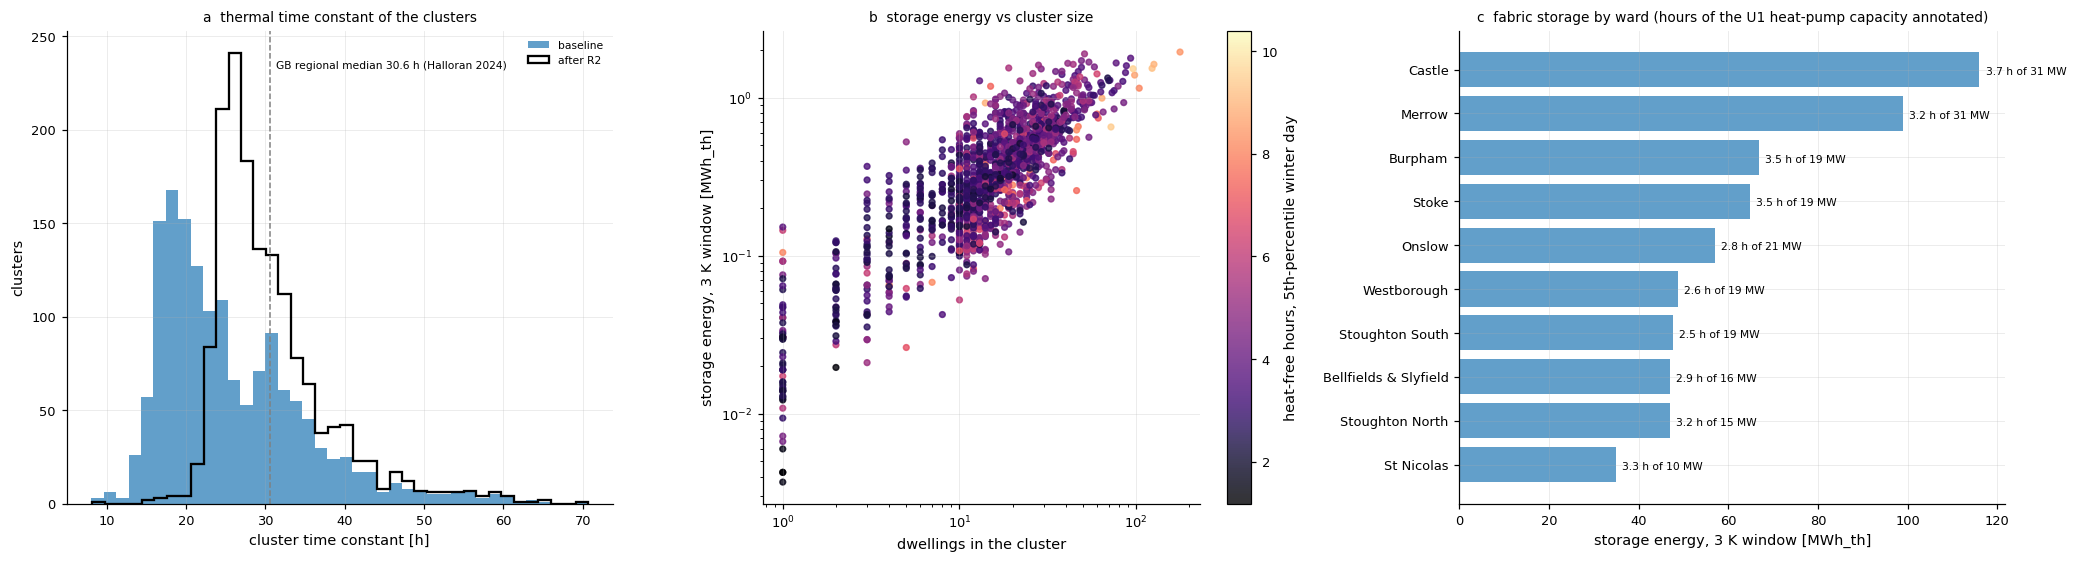

In [11]:
if fx_file.exists():
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
    axes[0].hist(cf["time_constant_h_mean"].clip(upper=120), bins=40, color="tab:blue", alpha=0.7, label="baseline"); axes[0].hist(cf["time_constant_h_mean_after_R2"].clip(upper=120), bins=40, histtype="step", lw=1.5, color="k", label="after R2")
    axes[0].axvline(30.6, color="grey", ls="--", lw=1); axes[0].annotate("GB regional median 30.6 h (Halloran 2024)", (30.6, axes[0].get_ylim()[1] * 0.92), fontsize=7, xytext=(4, 0), textcoords="offset points")
    axes[0].set_xlabel("cluster time constant [h]"); axes[0].set_ylabel("clusters"); axes[0].set_title("a  thermal time constant of the clusters", fontsize=9); axes[0].legend(fontsize=7)
    sc = axes[1].scatter(cf["dwellings"], cf["tes_energy_kWh"] / 1e3, c=cf["heat_free_hours_p5_mean"], cmap="magma", s=14, alpha=0.8); plt.colorbar(sc, ax=axes[1], label="heat-free hours, 5th-percentile winter day")
    axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_xlabel("dwellings in the cluster"); axes[1].set_ylabel("storage energy, 3 K window [MWh_th]"); axes[1].set_title("b  storage energy vs cluster size", fontsize=9)
    wardflex = flex.drop(columns=["ward"], errors="ignore").join(scope[["ward"]]).groupby("ward").agg(tes_MWh=("tes_energy_kWh", lambda x: x.sum() / 1e3), hp_MW=("ashp_kW_U1", lambda x: x.sum() / 1e3)).sort_values("tes_MWh")
    axes[2].barh(wardflex.index, wardflex["tes_MWh"], color="tab:blue", alpha=0.7); axes[2].set_xlabel("storage energy, 3 K window [MWh_th]"); axes[2].set_title("c  fabric storage by ward (hours of the U1 heat-pump capacity annotated)", fontsize=9)
    for k, (w_, r_) in enumerate(wardflex.iterrows()): axes[2].annotate(f"{r_['tes_MWh'] / max(r_['hp_MW'], 1e-9):.1f} h of {r_['hp_MW']:.0f} MW", (r_["tes_MWh"], k), textcoords="offset points", xytext=(4, -3), fontsize=7)
    plt.tight_layout(); pubstyle.save_fig(fig, FIG_PX / "11_flexibility"); plt.show()

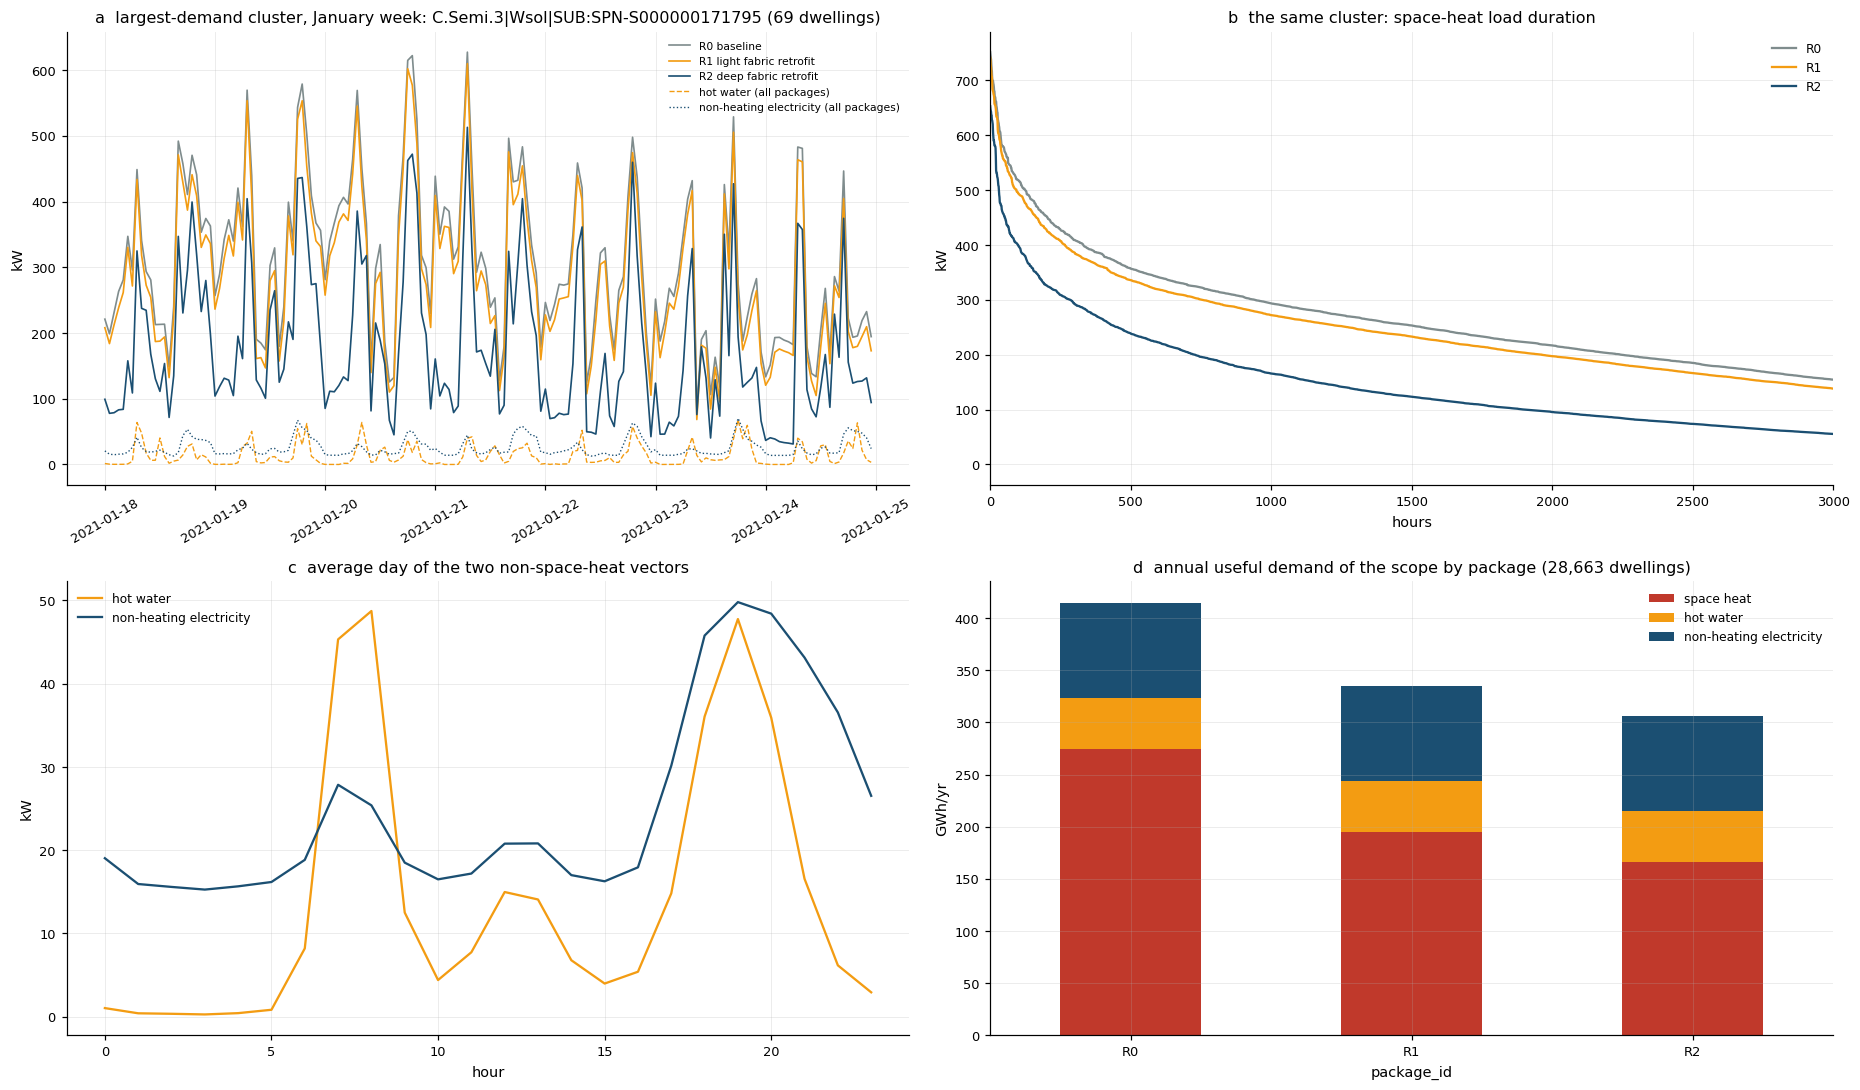

In [12]:
big = totals[totals["package_id"] == "R0"].sort_values("space_heat_kWh", ascending=False).iloc[0]["cluster_id"]   # the cluster with the largest annual space heat
prof = pd.read_parquet(OUT_PX / "demand_profiles.parquet", filters=[("cluster_id", "==", big)])
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
w = (prof["timestamp_utc"] >= "2021-01-18") & (prof["timestamp_utc"] < "2021-01-25")
for pkg, col in pubstyle.PACKAGE_COLOURS.items():
    pp = prof[(prof["package_id"] == pkg) & w]; axes[0, 0].plot(pp["timestamp_utc"], pp["space_heat_kw"], color=col, lw=1.1, label=f"{pkg} {PX.R_PACKAGES[pkg]['name']}")
pp = prof[(prof["package_id"] == "R0") & w]; axes[0, 0].plot(pp["timestamp_utc"], pp["hot_water_heat_kw"], color=pubstyle.VECTOR_COLOURS["hot_water_heat_kw"], lw=0.9, ls="--", label="hot water (all packages)")
axes[0, 0].plot(pp["timestamp_utc"], pp["non_heating_electricity_kw"], color=pubstyle.VECTOR_COLOURS["non_heating_electricity_kw"], lw=0.9, ls=":", label="non-heating electricity (all packages)")
axes[0, 0].set_ylabel("kW"); axes[0, 0].set_title(f"a  largest-demand cluster, January week: {big} ({int(clusters.set_index('cluster_id').loc[big, 'dwelling_count'])} dwellings)"); axes[0, 0].legend(fontsize=7); axes[0, 0].tick_params(axis="x", rotation=30)
for pkg, col in pubstyle.PACKAGE_COLOURS.items():
    x = totals[totals["package_id"] == pkg]
    axes[0, 1].plot(np.arange(8760), profiles.load_duration(prof.loc[prof["package_id"] == pkg, "space_heat_kw"].to_numpy()), color=col, label=pkg)
axes[0, 1].set_xlim(0, 3000); axes[0, 1].set_xlabel("hours"); axes[0, 1].set_ylabel("kW"); axes[0, 1].set_title("b  the same cluster: space-heat load duration"); axes[0, 1].legend()
g0 = prof[prof["package_id"] == "R0"].set_index("timestamp_utc")
axes[1, 0].plot(range(24), g0["hot_water_heat_kw"].groupby(g0.index.hour).mean(), color=pubstyle.VECTOR_COLOURS["hot_water_heat_kw"], label="hot water"); axes[1, 0].plot(range(24), g0["non_heating_electricity_kw"].groupby(g0.index.hour).mean(), color=pubstyle.VECTOR_COLOURS["non_heating_electricity_kw"], label="non-heating electricity")
axes[1, 0].set_xlabel("hour"); axes[1, 0].set_ylabel("kW"); axes[1, 0].set_title("c  average day of the two non-space-heat vectors"); axes[1, 0].legend()
tot_pkg = totals.groupby("package_id")[["space_heat_kWh", "hot_water_kWh", "non_heating_elec_kWh"]].sum() / 1e6
tot_pkg.rename(columns={"space_heat_kWh": "space heat", "hot_water_kWh": "hot water", "non_heating_elec_kWh": "non-heating electricity"}).plot.bar(ax=axes[1, 1], stacked=True, rot=0, color=[pubstyle.VECTOR_COLOURS[c] for c in ("space_heat_kw", "hot_water_heat_kw", "non_heating_electricity_kw")]); axes[1, 1].set_ylabel("GWh/yr"); axes[1, 1].set_title(f"d  annual useful demand of the scope by package ({len(scope):,} dwellings)")
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PX / "11_demand_profiles"); plt.show()

## What is in `outputs/pypsa_interface/`

`building_cluster_map.csv`, `cluster_summary.csv`, `retrofit_options.csv`, `measure_sets.json`,
`thermal_parameter_sets.json`, `retrofit_quantities.csv`, `demand_profiles.parquet`,
`demand_profile_library.parquet`, `demand_profile_library_heat_pump.parquet`, `cluster_profile_weights.csv`,
`cluster_annual_totals.csv`, `cluster_flexibility.csv`, `cases.csv` and `README_pypsa_interface.md`
(schema, boundaries, units). Figures in `outputs/figures/pypsa_interface/` as PNG + PDF at 300 dpi.